# A/B-тест: влияние рекламы на конверсию

**Датасет:** Marketing A/B Testing (Kaggle) — ~588 тыс. пользователей.

**Цель:** проверить, повышает ли реклама конверсию в покупку; является ли этот эффект статистически значимым.

## Загрузка и первичный осмотр данных

In [22]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

ab = pd.read_csv('data/marketing_AB.csv')
print(f"Размер: {len(ab):,} записей")
print(f"\nГруппы:\n{ab['test group'].value_counts()}")
print(f"\nКонверсия по группам:\n{ab.groupby('test group')['converted'].mean().apply(lambda x: f'{x:.3%}')}")

Размер: 588,101 записей

Группы:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Конверсия по группам:
test group
ad     2.555%
psa    1.785%
Name: converted, dtype: object


In [ ]:
**Вывод:** данные чистые — 588 101 запись, пропусков нет. 

Группы: ad — видели рекламу продукта, psa — видели социальную рекламу (не про продукт).

## A/B-тест: сравнение конверсии

Проверяем гипотезу: реклама повышает конверсию в покупку.

In [17]:

ad = ab[ab['test group'] == 'ad']['converted'].astype(int)
psa = ab[ab['test group'] == 'psa']['converted'].astype(int)

print(f"Группа ad (реклама):  {len(ad):,} чел, конверсия {ad.mean():.3%}")
print(f"Группа psa (контроль): {len(psa):,} чел, конверсия {psa.mean():.3%}")

t_stat, p_value = stats.ttest_ind(ad, psa)
print(f"\nP-value: {p_value:.6f}")
print(f"Значимо: {'да' if p_value < 0.05 else 'нет'}")



Группа ad (реклама):  564,577 чел, конверсия 2.555%
Группа psa (контроль): 23,524 чел, конверсия 1.785%

P-value: 0.000000
Значимо: да


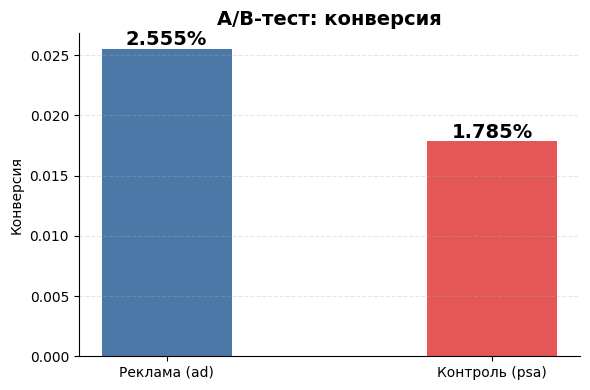

In [18]:
# График
plt.figure(figsize=(6, 4))
rates = [ad.mean(), psa.mean()]
plt.bar(['Реклама (ad)', 'Контроль (psa)'], rates, color=['#4C78A8', '#E45756'], width=0.4)
for i, r in enumerate(rates):
    plt.text(i, r + 0.0003, f'{r:.3%}', ha='center', fontsize=14, fontweight='bold')
plt.title('A/B-тест: конверсия', fontsize=14, fontweight='bold')
plt.ylabel('Конверсия')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
**Результат:**

- Ad (реклама): 2.55%
- PSA (контроль): 1.79%
- Разница: 0.76 п.п.
- P-value < 0.001 — разница статистически значима

**Вывод:** рекламная кампания эффективна. Показ рекламы повышает конверсию примерно на 76 процентов.

## Конверсия по дням недели

Посмотрим, в какой день недели реклама работает лучше всего.

In [14]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_group_conv = ab.groupby(['most ads day', 'test group'])['converted'].mean().unstack().reindex(day_order)
day_group_conv

test group,ad,psa
most ads day,,
Monday,0.033241,0.022559
Tuesday,0.030440,0.014448
Wednesday,0.025356,0.015759
Thursday,0.021637,0.020230
Friday,0.022465,0.016303
Saturday,0.021307,0.013996
Sunday,0.024620,0.020595


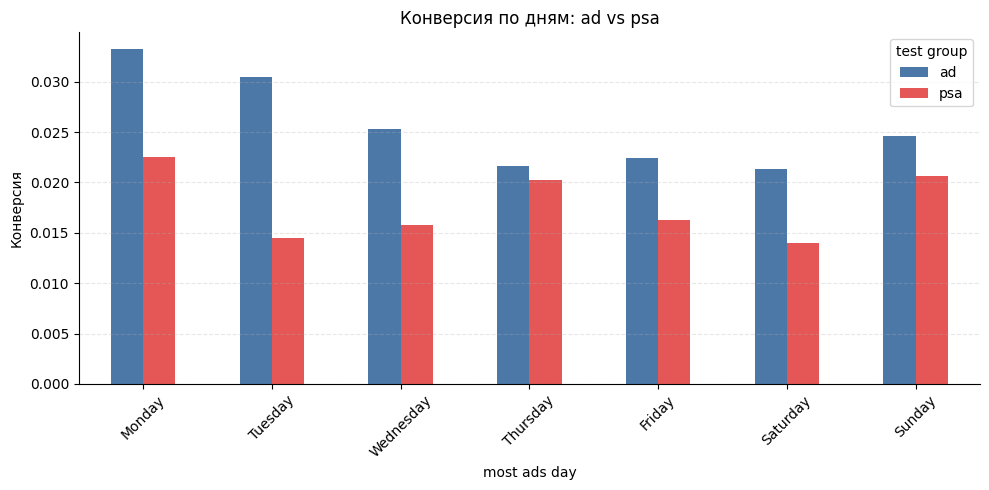

In [16]:
day_group_conv.plot(kind='bar', figsize=(10, 5), color=['#4C78A8', '#E45756'])
plt.title('Конверсия по дням: ad vs psa')
plt.ylabel('Конверсия')
plt.xticks(rotation=45)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


**Вывод:** реклама эффективнее в будние дни. Выходные показывают меньшую разницу между группами.

## Итоговый вывод

1. Рекламная кампания статистически значимо повышает конверсию (p-value < 0.001)
2. Эффект составляет ~0.76 п.п. — с 1.79% до 2.55%
3. Реклама наиболее эффективна в будние дни
